# Modelo Baseline — Logistic Regression

Modelo de clasificación binaria para predecir churn en D1. Se usa Logistic Regression como baseline para establecer un piso de performance antes de probar modelos más complejos.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

## 1. Carga de datos

In [2]:
X_train = pd.read_parquet('../data/splits/X_train.parquet')
X_test  = pd.read_parquet('../data/splits/X_test.parquet')
y_train = pd.read_parquet('../data/splits/y_train.parquet').squeeze()
y_test  = pd.read_parquet('../data/splits/y_test.parquet').squeeze()

print('Train:', X_train.shape)
print('Test: ', X_test.shape)

Train: (14807, 13)
Test:  (3702, 13)


In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
print('Entrenamiento completo')

Entrenamiento completo


In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

ROC-AUC: 0.7749


In [8]:
print(classification_report(y_test, y_pred, target_names=['Retuvo', 'Churnó']))

              precision    recall  f1-score   support

      Retuvo       0.68      0.69      0.69      1632
      Churnó       0.75      0.74      0.75      2070

    accuracy                           0.72      3702
   macro avg       0.71      0.72      0.72      3702
weighted avg       0.72      0.72      0.72      3702



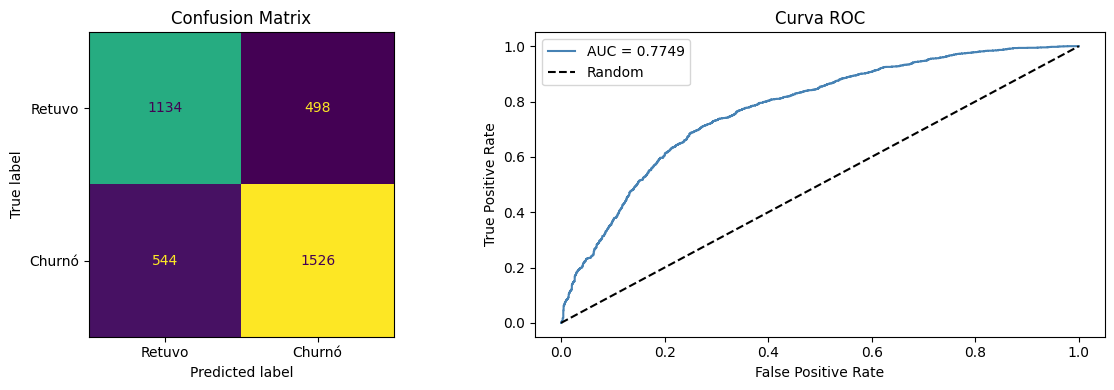

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Retuvo', 'Churnó'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Confusion Matrix')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

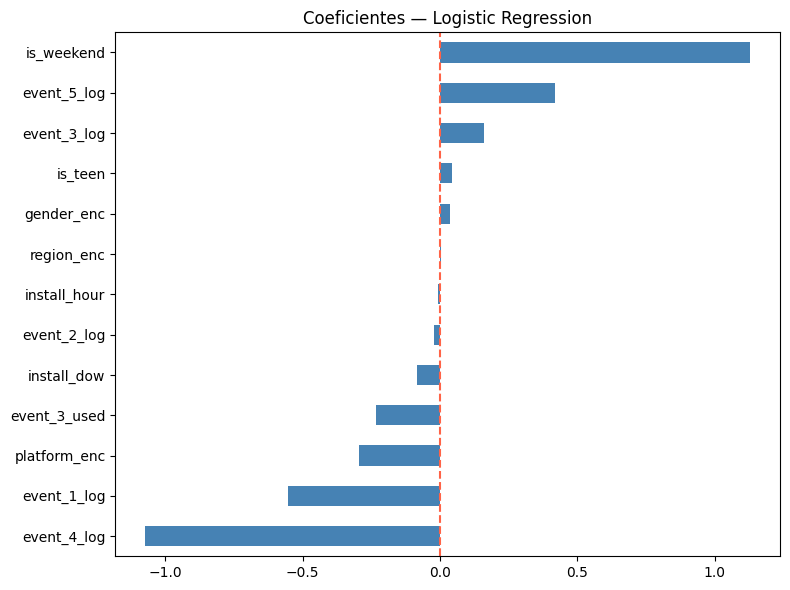

In [10]:
coefs = pd.Series(model.coef_[0], index=X_train.columns)
coefs.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.axvline(x=0, color='tomato', linestyle='--')
plt.title('Coeficientes — Logistic Regression')
plt.tight_layout()
plt.show()

**Conclusiones del baseline:**

**Performance:** ROC-AUC de 0.7749 con accuracy del 72% — un buen piso para un modelo lineal sin tuning.

**Feature importance:**
- `event_4_log` y `event_1_log` son los coeficientes negativos más fuertes (más eventos → menos churn), consistente con el EDA.
- `is_weekend` es el coeficiente positivo más fuerte — instalar en fin de semana aumenta significativamente el churn.
- `platform_enc` confirma lo del EDA: iOS retiene más.
- `event_2_log`, `region_enc` e `install_hour` tienen coeficientes casi cero — el modelo los ignora.

**Limitación:** la multicolinealidad entre eventos distorsiona algunos coeficientes. Un modelo no lineal como Random Forest o XGBoost no tiene este problema y debería capturar mejor las interacciones entre features.